In [1]:
import pandas as pd

In [ ]:
from google.colab import files

uploaded = files.upload()

In [ ]:
df = pd.read_csv('datasett.csv')

In [ ]:
df.shape

In [ ]:
df.columns

In [ ]:
df.isnull().sum()

,0
Date,0
Day,0
Month,0
Year,0
Customer_Age,0
Age_Group,0
Customer_Gender,0
Country,0
State,0
Product_Category,0


In [ ]:
df.duplicated().sum()

np.int64(1000)

In [ ]:
df[df.duplicated()].head()

,Date,Day,Month,Year,Customer_Age,Age_Group,Customer_Gender,Country,State,Product_Category,Sub_Category,Product,Order_Quantity,Unit_Cost,Unit_Price,Profit,Cost,Revenue
1021,19-12-2013,19,December,2013,22,Youth (<25),M,Australia,New South Wales,Accessories,Bike Stands,All-Purpose Bike Stand,9,59,159,714,531,1245
1091,30-09-2015,30,September,2015,42,Adults (35-64),F,Australia,Victoria,Accessories,Bottles and Cages,Mountain Bottle Cage,5,4,10,20,20,40
1093,24-10-2013,24,October,2013,42,Adults (35-64),F,Australia,Victoria,Accessories,Bottles and Cages,Mountain Bottle Cage,2,4,10,8,8,16
1095,24-10-2015,24,October,2015,42,Adults (35-64),F,Australia,Victoria,Accessories,Bottles and Cages,Mountain Bottle Cage,1,4,10,4,4,8
1193,15-01-2016,15,January,2016,42,Adults (35-64),M,France,Seine Saint Denis,Accessories,Bottles and Cages,Water Bottle - 30 oz.,14,2,5,29,28,57


In [ ]:
df = df.drop_duplicates()

In [ ]:
df = df.reset_index(drop=True)

In [ ]:
df.shape

(112036, 18)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.dtypes

,0
Date,object
Day,int64
Month,object
Year,int64
Customer_Age,int64
Age_Group,object
Customer_Gender,object
Country,object
State,object
Product_Category,object


In [ ]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

In [ ]:
df['Date'].dtype

dtype('<M8[ns]')

In [ ]:
df.describe()

,Date,Day,Year,Customer_Age,Order_Quantity,Unit_Cost,Unit_Price,Profit,Cost,Revenue
count,112036,112036.000000,112036.000000,112036.000000,112036.000000,112036.000000,112036.000000,112036.000000,112036.000000,112036.000000
mean,2014-11-23 05:22:32.008282880,15.665607,2014.400925,35.919508,11.904254,267.819603,453.850628,286.035194,471.103333,757.138527
min,2011-01-01 00:00:00,1.000000,2011.000000,17.000000,1.000000,1.000000,2.000000,-30.000000,1.000000,2.000000
25%,2013-12-22 00:00:00,8.000000,2013.000000,28.000000,2.000000,2.000000,5.000000,29.000000,28.000000,64.000000
50%,2014-06-27 00:00:00,16.000000,2014.000000,35.000000,10.000000,9.000000,25.000000,103.000000,112.000000,226.000000
75%,2016-01-09 00:00:00,23.000000,2016.000000,43.000000,20.000000,42.000000,70.000000,360.000000,442.000000,806.000000
max,2016-07-31 00:00:00,31.000000,2016.000000,87.000000,32.000000,2171.000000,3578.000000,15096.000000,42978.000000,58074.000000
std,NaN,8.781485,1.273327,11.016543,9.564877,550.218722,922.751848,454.852634,886.971635,1312.061623


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112036 entries, 0 to 112035
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Date              112036 non-null  datetime64[ns]
 1   Day               112036 non-null  int64         
 2   Month             112036 non-null  object        
 3   Year              112036 non-null  int64         
 4   Customer_Age      112036 non-null  int64         
 5   Age_Group         112036 non-null  object        
 6   Customer_Gender   112036 non-null  object        
 7   Country           112036 non-null  object        
 8   State             112036 non-null  object        
 9   Product_Category  112036 non-null  object        
 10  Sub_Category      112036 non-null  object        
 11  Product           112036 non-null  object        
 12  Order_Quantity    112036 non-null  int64         
 13  Unit_Cost         112036 non-null  int64         
 14  Unit

In [ ]:
df[['Customer_Age', 'Order_Quantity', 'Unit_Cost',
    'Unit_Price', 'Profit', 'Cost', 'Revenue']].min()

,0
Customer_Age,17
Order_Quantity,1
Unit_Cost,1
Unit_Price,2
Profit,-30
Cost,1
Revenue,2


In [ ]:
df[['Customer_Age', 'Order_Quantity', 'Unit_Cost',
    'Unit_Price', 'Profit', 'Cost', 'Revenue']].max()

,0
Customer_Age,87
Order_Quantity,32
Unit_Cost,2171
Unit_Price,3578
Profit,15096
Cost,42978
Revenue,58074


In [ ]:
df.nunique()

,0
Date,1884
Day,31
Month,12
Year,6
Customer_Age,70
Age_Group,4
Customer_Gender,2
Country,6
State,53
Product_Category,3


In [ ]:
df['Product_Category'].value_counts()

,count
Product_Category,
Accessories,69312
Bikes,25794
Clothing,16930


In [ ]:
df.groupby('Product_Category')['Revenue'].sum().sort_values(ascending=False)

,Revenue
Product_Category,
Bikes,61434484
Accessories,15022766
Clothing,8369522


In [ ]:
df.groupby('Product_Category')['Profit'].sum().sort_values(ascending=False)

,Profit
Product_Category,
Bikes,20399726
Accessories,8807194
Clothing,2839319


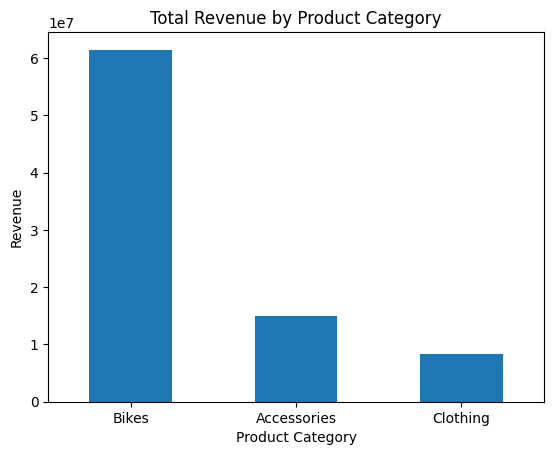

In [ ]:
import matplotlib.pyplot as plt

revenue_by_category = df.groupby('Product_Category')['Revenue'].sum().sort_values(ascending=False)

revenue_by_category.plot(kind='bar')

plt.title('Total Revenue by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Revenue')
plt.xticks(rotation=0)
plt.show()

In [ ]:
category_summary = df.groupby('Product_Category').agg({
    'Order_Quantity': 'sum',
    'Revenue': 'sum',
    'Profit': 'sum',
    'Cost': 'sum'
}).sort_values('Revenue', ascending=False)

category_summary

,Order_Quantity,Revenue,Profit,Cost
Product_Category,,,,
Bikes,36201,61434484,20399726,41034758
Accessories,1042791,15022766,8807194,6215572
Clothing,254713,8369522,2839319,5530203


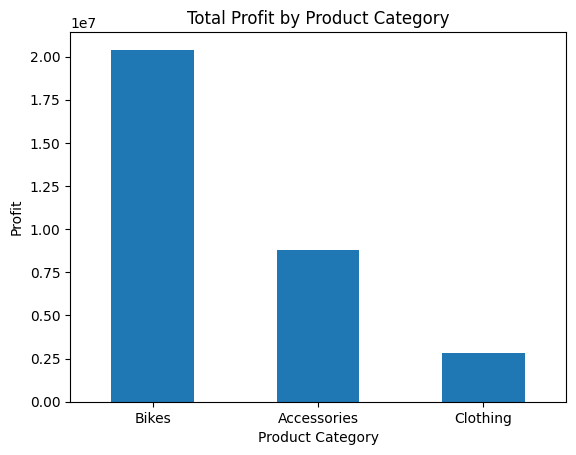

In [ ]:
profit_by_category = df.groupby('Product_Category')['Profit'].sum().sort_values(ascending=False)

profit_by_category.plot(kind='bar')

plt.title('Total Profit by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Profit')
plt.xticks(rotation=0)
plt.show()

In [ ]:
revenue_by_country = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False)

revenue_by_country

,Revenue
Country,
United States,27777098
Australia,21196395
United Kingdom,10575628
Germany,8956724
France,8414745
Canada,7906182


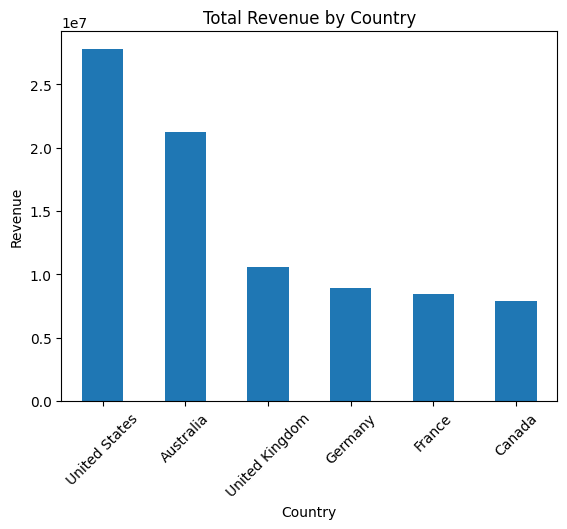

In [ ]:
revenue_by_country.plot(kind='bar')

plt.title('Total Revenue by Country')
plt.xlabel('Country')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.show()

In [ ]:
country_category_revenue = df.groupby(
    ['Country', 'Product_Category']
)['Revenue'].sum().unstack()

country_category_revenue

Product_Category,Accessories,Bikes,Clothing
Country,,,
Australia,2727399,16867194,1601802
Canada,2265769,4262618,1377795
France,1377060,6316991,720694
Germany,1538472,6781256,636996
United Kingdom,1862978,7796471,916179
United States,5251088,19409954,3116056


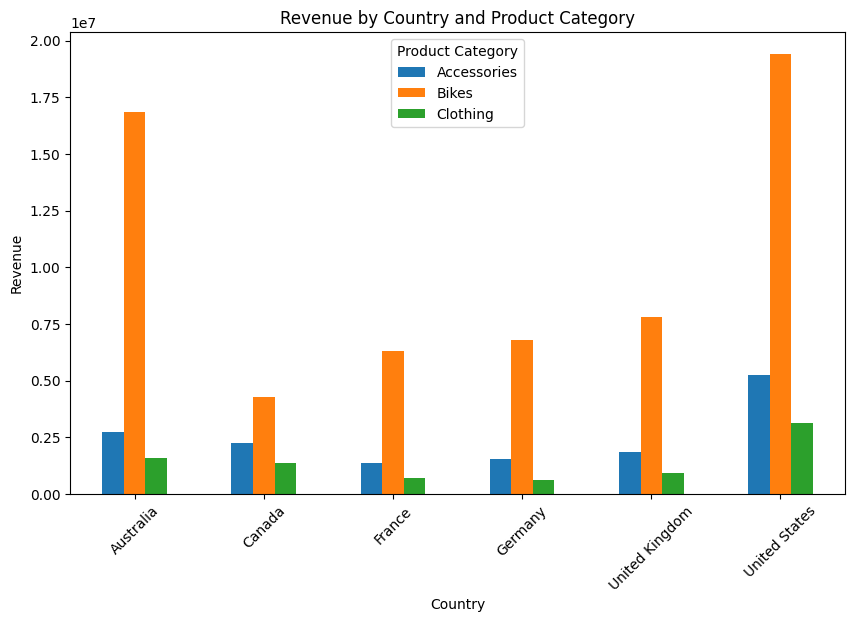

In [ ]:
country_category_revenue.plot(kind='bar', figsize=(10, 6))

plt.title('Revenue by Country and Product Category')
plt.xlabel('Country')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.legend(title='Product Category')
plt.show()

In [ ]:
revenue_by_year = df.groupby('Year')['Revenue'].sum()

revenue_by_year

,Revenue
Year,
2011,8951966
2012,9133795
2013,15117327
2014,14040192
2015,19945703
2016,17637789


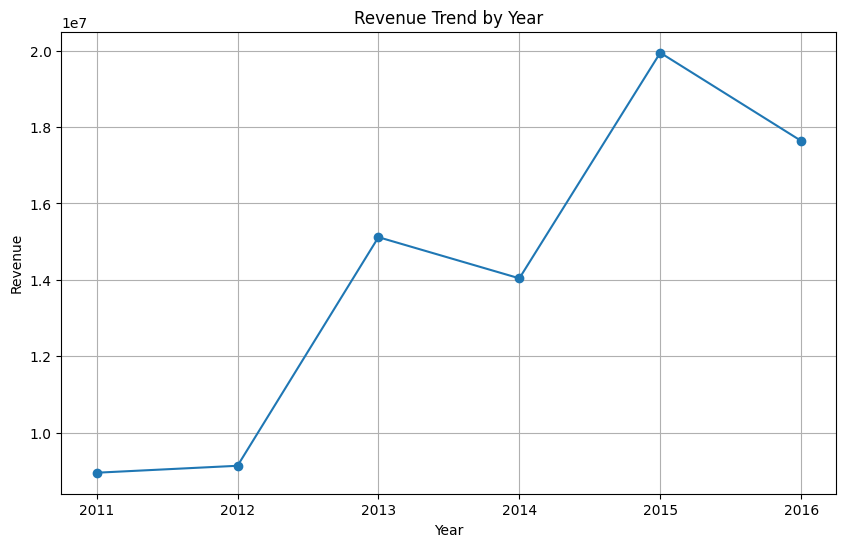

In [ ]:
revenue_by_year.plot(kind='line', marker='o', figsize=(10, 6))

plt.title('Revenue Trend by Year')
plt.xlabel('Year')
plt.ylabel('Revenue')
plt.xticks(revenue_by_year.index)
plt.grid(True)
plt.show()

In [ ]:
revenue_by_month = df.groupby('Month')['Revenue'].sum()

revenue_by_month

,Revenue
Month,
April,7568874
August,5692947
December,9046323
February,6805834
January,6961166
July,5691960
June,8978817
March,7306140
May,8789287


In [ ]:
month_order = [
    'January', 'February', 'March', 'April',
    'May', 'June', 'July', 'August',
    'September', 'October', 'November', 'December'
]

revenue_by_month = revenue_by_month.reindex(month_order)

revenue_by_month

,Revenue
Month,
January,6961166
February,6805834
March,7306140
April,7568874
May,8789287
June,8978817
July,5691960
August,5692947
September,5822197


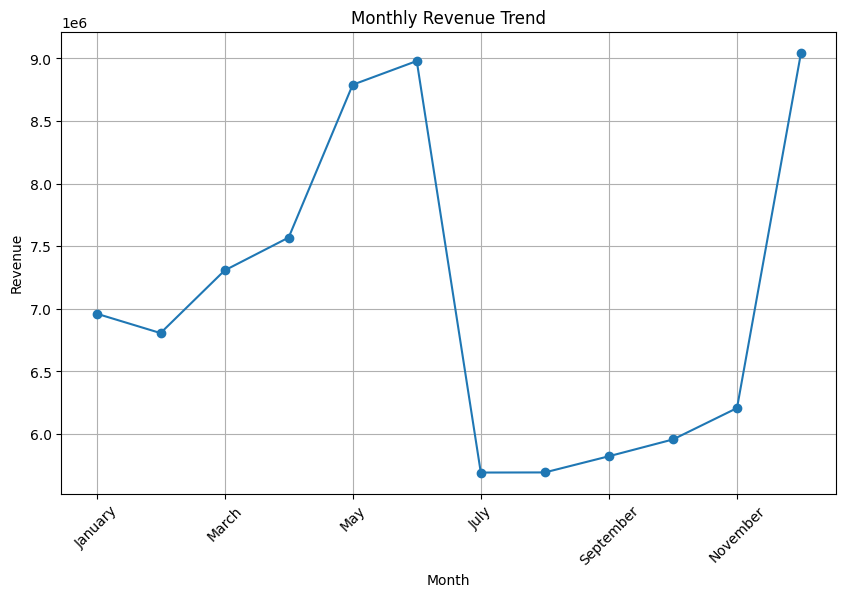

In [ ]:
revenue_by_month.plot(kind='line', marker='o', figsize=(10, 6))

plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [ ]:
monthly_year_revenue = df.groupby(['Year', 'Month'])['Revenue'].sum().unstack()

monthly_year_revenue

Month,April,August,December,February,January,July,June,March,May,November,October,September
Year,,,,,,,,,,,,
2011,698782.0,880037.0,1132666.0,635179.0,675193.0,882219.0,654977.0,703081.0,734537.0,572592.0,696949.0,685754.0
2012,729947.0,927504.0,1110101.0,637820.0,671695.0,863284.0,685548.0,729951.0,763465.0,594590.0,723925.0,695965.0
2013,472219.0,1751517.0,2968056.0,483909.0,426890.0,1215265.0,530123.0,466422.0,585185.0,2211883.0,2024682.0,1981176.0
2014,2188979.0,NaN,NaN,1934409.0,1991633.0,515765.0,2754626.0,2092223.0,2562557.0,NaN,NaN,NaN
2015,730392.0,2133889.0,3835500.0,678171.0,660671.0,1717003.0,784598.0,714008.0,893563.0,2827886.0,2510720.0,2459302.0
2016,2748555.0,NaN,NaN,2436346.0,2535084.0,498424.0,3568945.0,2600455.0,3249980.0,NaN,NaN,NaN


In [ ]:
profit_margin_by_category = df.groupby('Product_Category').agg({
    'Revenue': 'sum',
    'Profit': 'sum'
})

profit_margin_by_category['Profit_Margin_%'] = (
    profit_margin_by_category['Profit'] /
    profit_margin_by_category['Revenue']
) * 100

profit_margin_by_category

,Revenue,Profit,Profit_Margin_%
Product_Category,,,
Accessories,15022766,8807194,58.625649
Bikes,61434484,20399726,33.205660
Clothing,8369522,2839319,33.924506


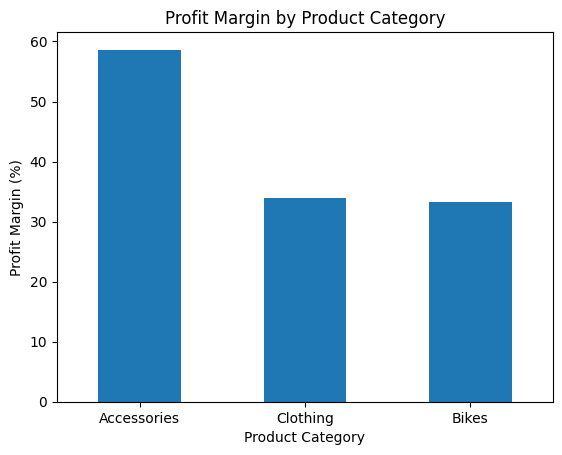

In [ ]:
profit_margin = profit_margin_by_category['Profit_Margin_%'].sort_values(ascending=False)

profit_margin.plot(kind='bar')

plt.title('Profit Margin by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Profit Margin (%)')
plt.xticks(rotation=0)
plt.show()

In [ ]:
revenue_by_age_group = df.groupby('Age_Group')['Revenue'].sum().sort_values(ascending=False)

revenue_by_age_group

,Revenue
Age_Group,
Adults (35-64),42367181
Young Adults (25-34),30467032
Youth (<25),11685489
Seniors (64+),307070


In [ ]:
orders_by_age_group = df.groupby('Age_Group')['Order_Quantity'].sum().sort_values(ascending=False)

orders_by_age_group

,Order_Quantity
Age_Group,
Adults (35-64),667098
Young Adults (25-34),442977
Youth (<25),213923
Seniors (64+),9707


In [ ]:
revenue_by_gender = df.groupby('Customer_Gender')['Revenue'].sum().sort_values(ascending=False)

revenue_by_gender

,Revenue
Customer_Gender,
M,43132083
F,41694689


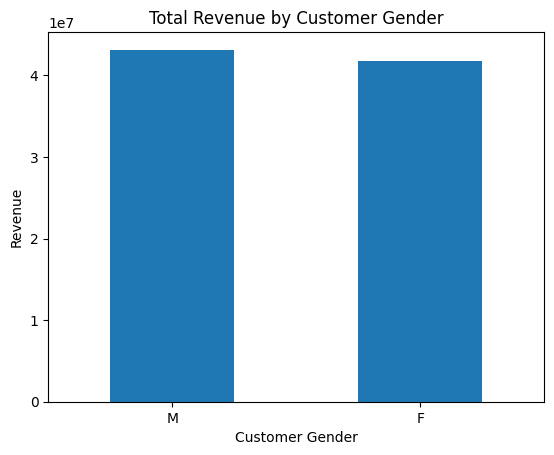

In [ ]:
revenue_by_gender.plot(kind='bar')

plt.title('Total Revenue by Customer Gender')
plt.xlabel('Customer Gender')
plt.ylabel('Revenue')
plt.xticks(rotation=0)
plt.show()

In [ ]:
top_products = df.groupby('Product')['Revenue'].sum().sort_values(ascending=False).head(10)

top_products

,Revenue
Product,
"Road-150 Red, 62",3810023
"Mountain-200 Black, 38",3345501
"Road-150 Red, 52",3152610
"Road-150 Red, 56",3142811
"Mountain-200 Silver, 42",3070174
"Mountain-200 Silver, 38",3011267
"Road-150 Red, 48",2955506
"Mountain-200 Black, 46",2756837
"Mountain-200 Black, 42",2630865


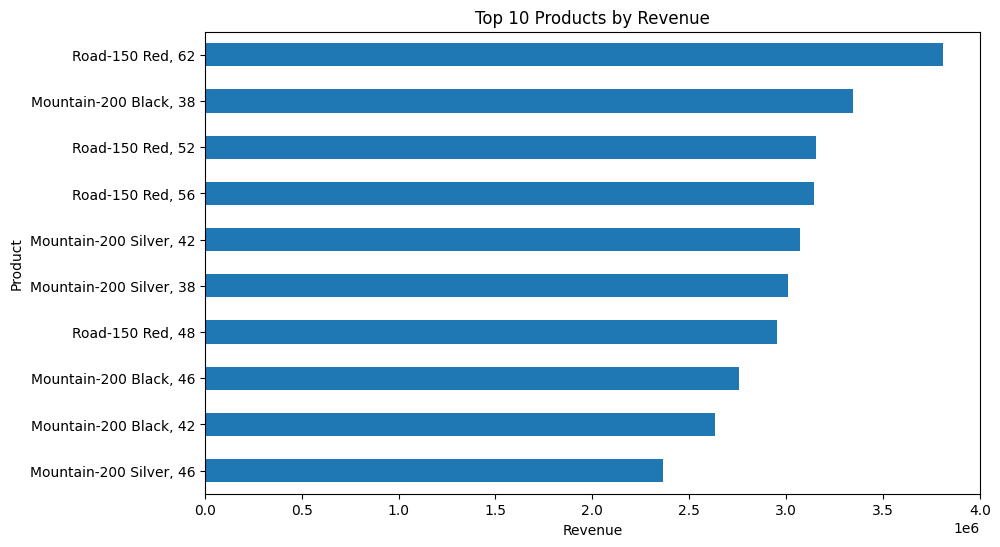

In [ ]:
top_products.sort_values().plot(kind='barh', figsize=(10, 6))

plt.title('Top 10 Products by Revenue')
plt.xlabel('Revenue')
plt.ylabel('Product')
plt.show()

In [ ]:
top_states = df.groupby('State')['Revenue'].sum().sort_values(ascending=False).head(10)

top_states

,Revenue
State,
California,17529787
England,10575628
New South Wales,9125980
British Columbia,7848334
Washington,6701258
Queensland,5055843
Victoria,5038294
Oregon,3435046
Hessen,2067980


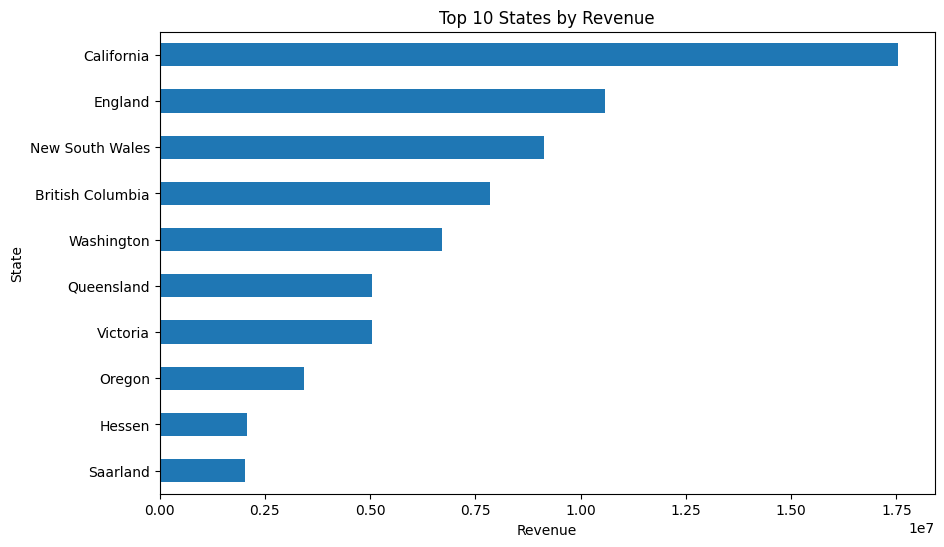

In [ ]:
top_states.sort_values().plot(kind='barh', figsize=(10, 6))

plt.title('Top 10 States by Revenue')
plt.xlabel('Revenue')
plt.ylabel('State')
plt.show()

## 10. Key Findings


After analyzing the dataset, I found a few important points:

- **Bikes generated the highest revenue**, with around 61.43 million in revenue.
- **Accessories had the highest profit margin**, at around 58.63%, even though their total revenue was lower than Bikes.
- The **United States had the highest revenue** among the countries, with around 27.78 million.
- **2015 had the highest yearly revenue**, with around 19.95 million.
- The **35-64 age group generated the highest revenue**, contributing around 42.37 million.
- **California was the highest-revenue region** among the top 10 regions analyzed.
- **Accessories had the highest number of orders**, while Bikes generated the highest overall revenue.

## 11. Business Recommendations

Based on the results of the analysis, a few actions could be considered:

- Since **Bikes generated the highest revenue**, the business can focus more on their sales and make sure popular bike products are available.
- **Accessories had a high profit margin**, so promoting these products more could help increase profits.
- Since the **United States generated the highest revenue**, customer preferences in this market can be studied further to understand what is driving sales.
- The strong performance of **California** can be studied to identify strategies that could also work in other regions.
- Since the **35-64 age group generated the highest revenue**, marketing campaigns can be designed around the preferences of this customer group.
- Looking at previous yearly sales trends can also help the business plan its future sales and inventory.

## 12. Conclusion

In this project, I analyzed retail sales data using Python and Pandas to understand different patterns in sales and profit.

I looked at products, categories, countries, regions, customer age groups, and yearly sales trends. The analysis showed that Bikes generated the highest revenue, while Accessories had the highest profit margin. I also found that the United States and the 35-64 age group contributed strongly to overall revenue.

Overall, this analysis helped me understand how data can be used to find useful patterns in a business dataset and turn those findings into simple business insights.